In [1]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')



# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()
# -------------------------------


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import os
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import SUB_PATH, Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES
metric_name = cfg.LIB_PARAMS["histgb"]["metric"]


from src.data_loader import load_data, prepare_data
from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_model, evaluate_metric
from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing
from src.data_splitter import DataSplitter
from src.experiment_tracker import ExperimentTracker
from sklearn.utils import compute_class_weight

# -------------------------------------------------------



sys.path contains: /home/ismail/Documents/projects/ml-projects/x42


In [2]:
# -------------------------------
# Load & prepare data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True
)

y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

# -------------------------------
# Data splitter
# -------------------------------
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=RANDOM_STATE,
    folds_path="data/folds.npy"
)
folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


Number of classes: 3
X_train shape: (76518, 36)
X_test shape: (51012, 36)
y_train shape: (76518,)
y_test labels are not available
Test IDs available: 51012
✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 76518
Total folds: 5

Fold 0: Train size=61214, Val size=15304
Fold 1: Train size=61214, Val size=15304
Fold 2: Train size=61214, Val size=15304
Fold 3: Train size=61215, Val size=15303
Fold 4: Train size=61215, Val size=15303


In [3]:
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import optuna
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):

    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    max_iter = trial.suggest_int('max_iter', 200, getattr(cfg, "NUM_BOOST_ROUND", 1000))
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.3, log=True)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 2 ** max_depth)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 100)

    param = {
        "loss": metric_name,  # ✅ loss works for binary & multiclass
        "max_iter": max_iter,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "max_leaf_nodes": max_leaf_nodes,
        "min_samples_leaf": min_samples_leaf,
        "l2_regularization": trial.suggest_float('l2_regularization', 1e-6, 10.0, log=True),
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        
        
        'early_stopping': True,
        'validation_fraction': 0.1,
        'n_iter_no_change': 50,
    
    }

    # -------------------------------
    # Class weights
    # -------------------------------
    if cfg.TASK.lower() == "binary":
        class_weight = "balanced" if getattr(cfg, "IS_UNBALANCE", True) else None
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        classes = np.unique(y_train_numeric)
        class_weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        class_weight = {c: w for c, w in zip(classes, class_weights)}
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    # -------------------------------
    # Stratified folds
    # -------------------------------
    fold_results = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        model = HistGradientBoostingClassifier(
            **param,
            class_weight=class_weight,

        )

        model.fit(X_tr, y_tr)

        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        # ✅ FIX HERE
        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val


        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
        else:
            fold_score = log_loss(y_val, pred_val)

        fold_results.append((n_fold, fold_score, model.n_iter_))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        if len(X_train) > getattr(cfg, "LARGE_DATASET_THRESHOLD", 500_000):
            gc.collect()

    gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        if cfg.TASK.lower() == "binary":
            # convert 1D probability to 2D for log_loss
            oof_probs = np.column_stack([1 - oof_preds, oof_preds])
        else:
            oof_probs = oof_preds
        mean_score = log_loss(y_train_numeric, oof_probs)

    best_iter = int(np.round(np.mean([f[2] for f in fold_results])))

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*" * 50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Best iteration: {iter_:>5d}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*" * 50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score

Number of classes: 3



Training final model on full training data...
---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.982471
1  Log Loss  0.257314
2  Accuracy  0.915262
Best mean CV score across all trials: 0.4583640796431108
OOF accuracy: 0.82172


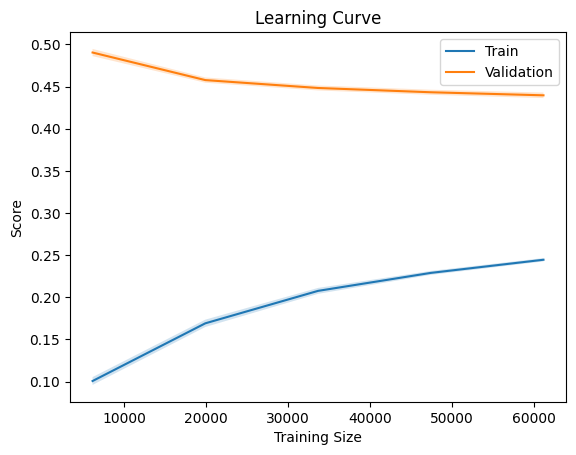


🔥 BEST STRATEGY: {'mode': 'thresholds', 'thr_0': 0.5971984359558402, 'thr_1': 0.7532112473687897, 'thr_2': 0.35297054520639976}
🔥 BEST SEED: 1234
🔥 BEST SCORE: 0.8293374085396293
OOF accuracy after post-processing: 0.82961
Saved model → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260328-231304_histgb_CVScore0.4584_exp_20260328-2313_max_depth11_learning_rate0.030834348179355788/model.pkl
Saved params → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260328-231304_histgb_CVScore0.4584_exp_20260328-2313_max_depth11_learning_rate0.030834348179355788/params.json
Saved metrics → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260328-231304_histgb_CVScore0.4584_exp_20260328-2313_max_depth11_learning_rate0.030834348179355788/metrics.json
Saved training time → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260328-231304_histgb_CVScore0.4584_exp_20260328-2313_max_depth11_learning_rate0.03083434817935578

0

In [ ]:
import time
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import numpy as np
import gc
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

# -------------------------------
# Run Optuna optimization
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg)  # n_trials inside cfg
train_time = time.time() - start


# Extract OOF predictions
oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final HistGradientBoostingClassifier on full training data
# -------------------------------
best_params = study.best_params.copy()
best_iteration = study.best_trial.user_attrs.get("best_iteration", cfg.NUM_BOOST_ROUND)


best_params.update({
    "loss": metric_name,  # works for both binary & multiclass
    "random_state": getattr(cfg, "RANDOM_STATE", 42),
    "max_iter": best_iteration

})

print("\nTraining final model on full training data...")

final_model = HistGradientBoostingClassifier(
    **best_params,
    early_stopping=False,  # full data, no need to stop early
)
final_model.fit(X_train, y_train_numeric)



# -------------------------------
# Evaluate on training set
# -------------------------------
print("---------------- Train Set --------------------")
pred_train_proba = final_model.predict_proba(X_train)
y_pred_train_class = (pred_train_proba >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_train_proba.argmax(axis=1)
metrics_df, _ = evaluate_model(y_train_numeric, pred_train_proba, task=cfg.TASK)
print(metrics_df)
print("Best mean CV score across all trials:", study.best_value)

# Evaluate OOF
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")



from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=y_train_numeric,
    cv=5,
    scoring="roc_auc" if cfg.TASK.lower() == "binary" else "neg_log_loss",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

# Fix sign if log loss
if cfg.TASK.lower() != "binary":
    train_mean = -train_mean
    valid_mean = -valid_mean

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, valid_mean, label="Validation")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
train_std = train_scores.std(axis=1)
valid_std = valid_scores.std(axis=1)

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
plt.show()



# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = None
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)
    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")
    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK.lower() == "binary" else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK.lower() == "binary" else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# Experiment Tracking
# -------------------------------
from src.experiment_tracker import ExperimentTracker
tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="histgb",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)
gc.collect()

# ExtraTrees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import gc

num_classes = len(np.unique(y_train_numeric))
print(f"Number of classes: {num_classes}")

# -------------------------------
# Optuna objective function
# -------------------------------
def objective(trial):
    # -------------------------------
    # Hyperparameter search space
    # -------------------------------
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 50)
    max_features = trial.suggest_float("max_features", 0.1, 1.0)

    param = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "random_state": getattr(cfg, "RANDOM_STATE", 42),
        "n_jobs": -1,
        # "class_weight": "balanced" if getattr(cfg, "IS_UNBALANCE", True) else None,
        'class_weight': trial.suggest_categorical(
            'class_weight', [None, 'balanced', 'balanced_subsample']
        ),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
    }

    # -------------------------------
    # Class weights & OOF init
    # -------------------------------
    if cfg.TASK.lower() == "binary":
        oof_preds = np.zeros(len(y_train_numeric))
    else:
        oof_preds = np.zeros((len(y_train_numeric), num_classes))

    # -------------------------------
    # Fold tracking
    # -------------------------------
    fold_results = []
    auc_scores = []
    logloss_scores = []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        model = ExtraTreesClassifier(**param)
        model.fit(X_tr, y_tr)

        # -------------------------------
        # Predictions for OOF
        # -------------------------------
        pred_val = model.predict_proba(X_val)

        if cfg.TASK.lower() == "binary":
            oof_preds[valid_idx] = pred_val[:, 1]
        else:
            oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Evaluate fold
        # -------------------------------
        if cfg.MAXIMIZE_METRIC:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val[:, 1])
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
            auc_scores.append(fold_score)
        else:
            if cfg.TASK.lower() == "binary":
                # log_loss needs 2D probs for binary
                fold_score = log_loss(y_val, pred_val)
            else:
                fold_score = log_loss(y_val, pred_val)
            logloss_scores.append(fold_score)

        fold_results.append((n_fold, fold_score, n_estimators))
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, X_tr, X_val, y_tr, y_val, pred_val
        gc.collect()

    # -------------------------------
    # True OOF score
    # -------------------------------
    if cfg.MAXIMIZE_METRIC:
        if cfg.TASK.lower() == "binary":
            mean_score = roc_auc_score(y_train_numeric, oof_preds)
        else:
            mean_score = roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if cfg.MAXIMIZE_METRIC else "LogLoss"
    print("\n" + "*"*50)
    for fold, score, n_tree in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Trees: {n_tree}")
    std_score = np.std([s for _, s, _ in fold_results])
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {std_score:.5f}")
    print("*"*50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)
    trial.set_user_attr("auc_scores", auc_scores)
    trial.set_user_attr("logloss_scores", logloss_scores)

    return mean_score




Number of classes: 3


In [ ]:
import time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import gc
import numpy as np

# -------------------------------
# Run Optuna study
# -------------------------------
start = time.time()
study = run_optuna(objective, cfg)  # n_trials parameter
train_time = time.time() - start

# -------------------------------
# Extract OOF predictions
# -------------------------------
oof_preds = study.best_trial.user_attrs['oof_preds']

# For ExtraTrees, we don't have per-iteration learning curves, but we can visualize fold results
# fold_results = study.best_trial.user_attrs.get('fold_results', [])
# plot_fold_scores(fold_results, metric_label="AUC" if cfg.MAXIMIZE_METRIC else "LogLoss")

# -------------------------------
# Train final ExtraTreesClassifier on full training data
# -------------------------------
best_params = study.best_params.copy()
best_params.update({
    "random_state": getattr(cfg, "RANDOM_STATE", 42),
    "n_jobs": -1,
    "class_weight": "balanced" if getattr(cfg, "IS_UNBALANCE", True) else None
})

print("\nTraining final ExtraTrees model on full training data...")
final_model = ExtraTreesClassifier(**best_params)
final_model.fit(X_train, y_train_numeric)

# -------------------------------
# Evaluate on train set
# -------------------------------
print("---------------- Train Set --------------------")

if cfg.TASK.lower() == "binary":
    pred_train_proba = final_model.predict_proba(X_train)[:, 1]
    y_pred_train_class = (pred_train_proba >= 0.5).astype(int)
else:
    pred_train_proba = final_model.predict_proba(X_train)
    y_pred_train_class = pred_train_proba.argmax(axis=1)

metrics_df, _ = evaluate_model(y_train_numeric, pred_train_proba, task=cfg.TASK)
print(metrics_df)
print("The best mean CV score across all trials:", study.best_value)




# OOF evaluation
if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)
print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")

# -------------------------------
# Optional post-processing
# -------------------------------
postprocessing_params = None
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]
    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=100,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)

    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )
    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")

    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL
    }

# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict_proba(X_test)
y_pred_class = (pred_test[:, 1] >= 0.5).astype(int) if cfg.TASK=='binary' else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test[:, 1]) if cfg.TASK=='binary' else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)

    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")

# -------------------------------
# ExperimentTracker
# -------------------------------
from src.experiment_tracker import ExperimentTracker

tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="extratrees",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)

gc.collect()

---------------- Train Set --------------------


     Metric     Value
0   ROC AUC  0.976751
1  Log Loss  0.304769
2  Accuracy  0.886902
The best mean CV score across all trials: 0.4517294201157055
OOF accuracy: 0.82577

🔥 BEST STRATEGY: {'mode': 'thresholds', 'thr_0': 0.4376390564677307, 'thr_1': 0.4808455962858241, 'thr_2': 0.49270645625779164}
🔥 BEST SEED: 42
🔥 BEST SCORE: 0.8262575015995682
OOF accuracy after post-processing: 0.82626
Saved model → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260329-002556_extratrees_CVScore0.4517_exp_20260329-0025_max_depth20/model.pkl
Saved params → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260329-002556_extratrees_CVScore0.4517_exp_20260329-0025_max_depth20/params.json
Saved metrics → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260329-002556_extratrees_CVScore0.4517_exp_20260329-0025_max_depth20/metrics.json
Saved training time → /home/ismail/Documents/projects/ml-projects/x42/outputs/experiments/20260329-002556_extr

267